# Lab Assignment
## 1. Import Library and load data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 2. Data Analysis

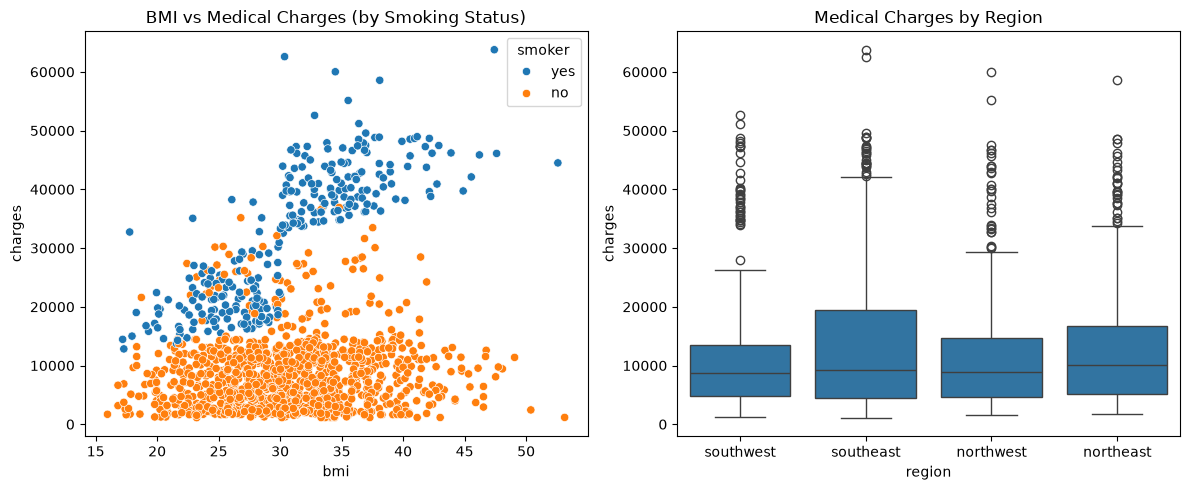

In [3]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker')
plt.title("BMI vs Medical Charges (by Smoking Status)")

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='region', y='charges')
plt.title("Medical Charges by Region")
plt.tight_layout()
plt.show()

## 3. Preprocessing

In [4]:
df_encoded = pd.get_dummies(df, drop_first=True)

## 4. Partition

In [5]:
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 5. Feature Scaling

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 6. Multiple Linear Regression

In [7]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

print("--- Multiple Linear Regression ---")
print(f"R-squared: {r2_score(y_test, y_pred_lr):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_lr):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_lr):.4f}")

--- Multiple Linear Regression ---
R-squared: 0.7836
MSE: 33596915.8514
MAE: 4181.1945


## 7. SVR

In [8]:
param_grid = {'C': [100, 1000, 5000], 'gamma': ['scale', 0.1, 0.01], 'kernel': ['rbf']}
svr = SVR()
grid_search = GridSearchCV(svr, param_grid, cv=5, scoring='r2')
grid_search.fit(X_train_scaled, y_train)

best_svr = grid_search.best_estimator_
y_pred_svr = best_svr.predict(X_test_scaled)

print("\n--- Support Vector Regression ---")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"R-squared: {r2_score(y_test, y_pred_svr):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_svr):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_svr):.4f}")


--- Support Vector Regression ---
Best Parameters: {'C': 5000, 'gamma': 0.1, 'kernel': 'rbf'}
R-squared: 0.8514
MSE: 23064535.2262
MAE: 1887.4518


## Result 
MAE measures the absolute difference between actual and predicted costs, while MSE measures the squared difference, and R-squared indicates how well the target data's variability is explained by the selected features

Multiple Linear Regression establishes a baseline slope for all features. But SVR utilizes support vectors—data points that significantly influence the model by defining the outer bounds of the prediction margins.